# Laboratorio 3 — Detección de Anomalías con Machine Learning

**Examen Práctico Final — Seguridad Informática**
**Estudiante:** Andrés Lino Montes Mamani
**Modelo:** Isolation Forest
**Dataset:** network_traffic.csv (10 000 registros de tráfico de red)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Librerías importadas correctamente')

Librerías importadas correctamente


## Tarea 3.1 — Exploración y Preprocesamiento

### 1. Carga del dataset y estadísticas descriptivas

In [2]:
df = pd.read_csv('network_traffic.csv')
print(f'Dimensiones del dataset: {df.shape}')
print(f'Columnas: {list(df.columns)}')
df.head()

Dimensiones del dataset: (10000, 10)
Columnas: ['timestamp', 'src_ip', 'dst_ip', 'dst_port', 'protocol', 'bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 'label']


,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label
0,2024-05-26 04:28:31,10.0.2.118,201.250.32.133,21,TCP,15310,45067,42.01,16,normal
1,2024-05-11 01:38:15,10.0.1.189,193.199.92.89,21,UDP,3692990,68116,55.35,2823,normal
2,2024-05-17 21:00:41,10.0.3.254,202.222.194.7,443,ICMP,23007,950555,6.64,18,normal
3,2024-05-09 18:30:38,10.0.1.254,152.183.142.33,25,TCP,467423,56148,3.12,656,normal
4,2024-05-27 17:50:29,10.0.3.87,64.39.138.32,3306,UDP,15355,18895,16.82,23,normal


In [3]:
df.describe()

,dst_port,bytes_sent,bytes_recv,duration_sec,packets
count,10000.000000,1.000000e+04,1.000000e+04,10000.000000,1.000000e+04
mean,5272.963700,2.815289e+07,4.124360e+05,447.154662,1.605501e+04
std,7348.395782,3.115671e+08,1.964278e+06,4530.488171,1.672859e+05
min,21.000000,1.500000e+01,0.000000e+00,0.000000,1.000000e+00
25%,53.000000,5.544000e+03,1.328800e+04,8.507500,5.000000e+00
50%,3389.000000,2.233900e+04,5.529050e+04,21.435000,2.400000e+01
75%,8080.000000,9.478175e+04,2.213258e+05,44.145000,1.100000e+02
max,65460.000000,4.987050e+09,8.155783e+07,83028.150000,2.939448e+06


In [4]:
print('Distribución de etiquetas (solo para validación):')
print(df['label'].value_counts())
print(f"\nPorcentaje de anomalías: {(df['label']=='anomaly').mean()*100:.2f}%")

Distribución de etiquetas (solo para validación):
label
normal     9500
anomaly     500
Name: count, dtype: int64

Porcentaje de anomalías: 5.00%


### 2. Visualización de distribuciones (histogramas)

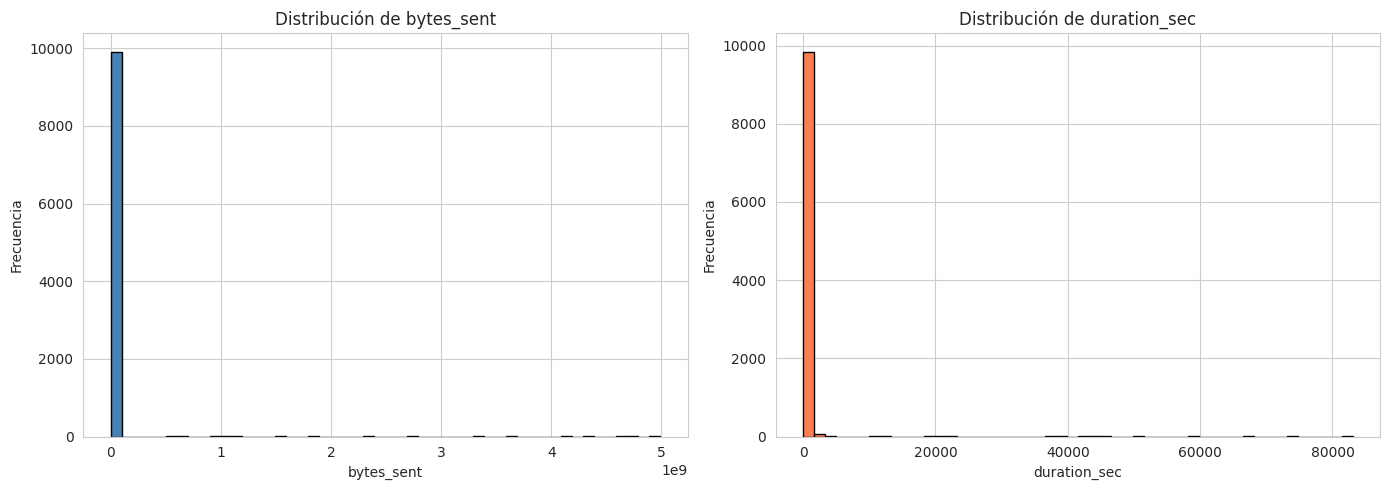

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['bytes_sent'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de bytes_sent')
axes[0].set_xlabel('bytes_sent')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df['duration_sec'], bins=50, color='coral', edgecolor='black')
axes[1].set_title('Distribución de duration_sec')
axes[1].set_xlabel('duration_sec')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('evidencias/SCR-3.1_eda.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. Identificación y tratamiento de valores nulos y atípicos

Se verifican valores nulos y se analiza la presencia de atípicos. 

**Nota importante:** en detección de anomalías NO se eliminan los valores atípicos extremos, ya que precisamente esos valores suelen corresponder al tráfico anómalo que el modelo debe detectar. En su lugar, se aplica una transformación logarítmica (`log1p`) para comprimir la escala de las variables con distribución muy sesgada, lo que mejora notablemente la separación entre tráfico normal y anómalo.

In [6]:
print('Valores nulos por columna:')
print(df.isnull().sum())

# Eliminar solo registros con nulos (no atípicos)
df = df.dropna()
print(f'\nDataset tras eliminar nulos: {df.shape}')

Valores nulos por columna:
timestamp       0
src_ip          0
dst_ip          0
dst_port        0
protocol        0
bytes_sent      0
bytes_recv      0
duration_sec    0
packets         0
label           0
dtype: int64

Dataset tras eliminar nulos: (10000, 10)


### 4. Feature Engineering — Creación de variables derivadas

Se crean dos nuevas variables derivadas:
- **ratio_bytes**: relación entre bytes enviados y recibidos (valores altos = posible exfiltración).
- **bytes_por_segundo**: tasa de transferencia de datos (valores extremos = comportamiento inusual).

In [7]:
df['ratio_bytes'] = df['bytes_sent'] / (df['bytes_recv'] + 1)
df['bytes_por_segundo'] = df['bytes_sent'] / (df['duration_sec'] + 0.001)

print('Nuevas variables creadas: ratio_bytes, bytes_por_segundo')
df[['bytes_sent', 'bytes_recv', 'ratio_bytes', 'duration_sec', 'bytes_por_segundo']].head()

Nuevas variables creadas: ratio_bytes, bytes_por_segundo


,bytes_sent,bytes_recv,ratio_bytes,duration_sec,bytes_por_segundo
0,15310,45067,0.339709,42.01,364.428364
1,3692990,68116,54.215394,55.35,66719.481130
2,23007,950555,0.024204,6.64,3464.387893
3,467423,56148,8.324690,3.12,149767.061839
4,15355,18895,0.812606,16.82,912.847036


### 5. Transformación logarítmica y normalización con StandardScaler

In [8]:
features = ['bytes_sent', 'bytes_recv', 'duration_sec', 'packets',
            'ratio_bytes', 'bytes_por_segundo']

# Transformación logarítmica para comprimir colas largas
df_log = df.copy()
for col in features:
    df_log[col] = np.log1p(df_log[col].clip(lower=0))

# Normalización
scaler = StandardScaler()
X = scaler.fit_transform(df_log[features])

# Etiqueta real solo para validación (NO se usa en entrenamiento)
y_true = (df['label'] == 'anomaly').astype(int).values

print(f'Features transformadas y normalizadas. Shape de X: {X.shape}')
print(f'Features usadas: {features}')

Features transformadas y normalizadas. Shape de X: (10000, 6)
Features usadas: ['bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 'ratio_bytes', 'bytes_por_segundo']


## Tarea 3.2 — Entrenamiento del Modelo

### 1. Entrenamiento de Isolation Forest (excluyendo la columna label)

In [9]:
model = IsolationForest(
    contamination=0.05,
    n_estimators=100,
    random_state=42
)
model.fit(X)
print('Modelo Isolation Forest entrenado')
print('Parámetros: contamination=0.05, n_estimators=100, random_state=42')

Modelo Isolation Forest entrenado
Parámetros: contamination=0.05, n_estimators=100, random_state=42


### 2. Predicciones (-1 = anomalía, 1 = normal)

In [10]:
y_pred_raw = model.predict(X)   # -1 anomalia, 1 normal
y_pred = (y_pred_raw == -1).astype(int)  # 1 anomalia, 0 normal

print(f'Anomalías detectadas: {y_pred.sum()}')
print(f'Registros normales: {(y_pred==0).sum()}')

Anomalías detectadas: 500
Registros normales: 9500


### 3. Métricas de evaluación (Precision, Recall, F1-Score)

In [11]:
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print('='*40)
print('MÉTRICAS DE EVALUACIÓN')
print('='*40)
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-Score  : {f1:.4f}')
print('='*40)

MÉTRICAS DE EVALUACIÓN
Precision : 0.8040
Recall    : 0.8040
F1-Score  : 0.8040


### 4. Matriz de confusión con seaborn

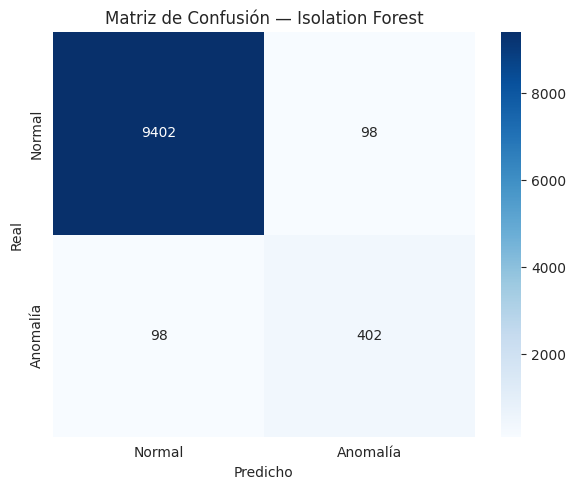

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomalía'],
            yticklabels=['Normal', 'Anomalía'])
plt.title('Matriz de Confusión — Isolation Forest')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig('evidencias/SCR-3.2_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

## Tarea 3.3 — Interpretación y Umbral Dinámico

### 1. Score de anomalía (decision_function) para todos los registros

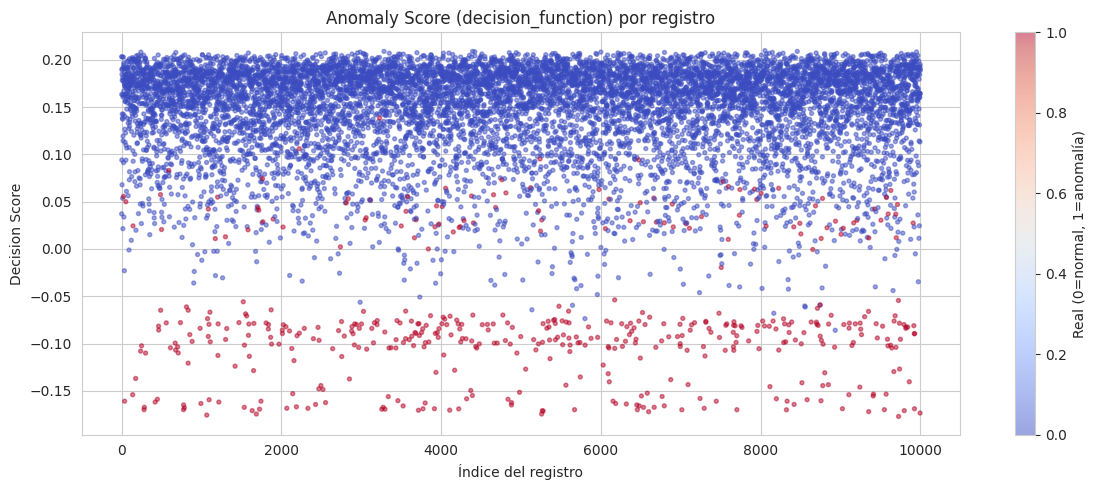

In [13]:
scores = model.decision_function(X)

plt.figure(figsize=(12, 5))
plt.scatter(range(len(scores)), scores, c=y_true, cmap='coolwarm', alpha=0.5, s=8)
plt.title('Anomaly Score (decision_function) por registro')
plt.xlabel('Índice del registro')
plt.ylabel('Decision Score')
plt.colorbar(label='Real (0=normal, 1=anomalía)')
plt.tight_layout()
plt.show()

### 2. Umbral óptimo que maximiza el F1-Score (curva umbral vs F1)

Umbral óptimo: -0.0528
Mejor F1-Score con umbral óptimo: 0.8801


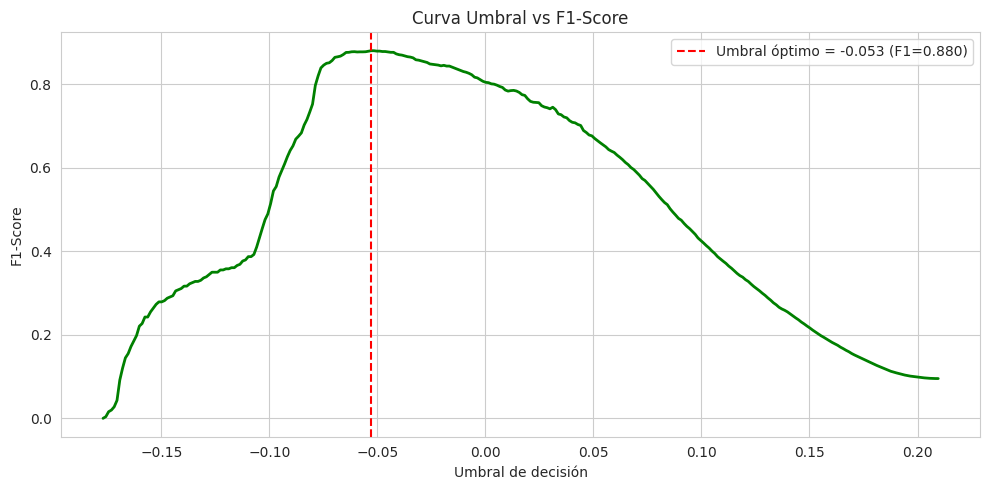

In [14]:
thresholds = np.linspace(scores.min(), scores.max(), 300)
f1_list = []
for t in thresholds:
    y_t = (scores < t).astype(int)
    f1_list.append(f1_score(y_true, y_t, zero_division=0))

best_idx = int(np.argmax(f1_list))
best_threshold = thresholds[best_idx]
best_f1 = f1_list[best_idx]

print(f'Umbral óptimo: {best_threshold:.4f}')
print(f'Mejor F1-Score con umbral óptimo: {best_f1:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_list, color='green', linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--',
            label=f'Umbral óptimo = {best_threshold:.3f} (F1={best_f1:.3f})')
plt.title('Curva Umbral vs F1-Score')
plt.xlabel('Umbral de decisión')
plt.ylabel('F1-Score')
plt.legend()
plt.tight_layout()
plt.savefig('evidencias/SCR-3.3_umbral_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. Top 10 registros más anómalos

In [15]:
df_result = df.copy()
df_result['anomaly_score'] = scores
top10 = df_result.nsmallest(10, 'anomaly_score')
top10[['src_ip', 'dst_ip', 'dst_port', 'protocol', 'bytes_sent',
       'bytes_recv', 'duration_sec', 'packets', 'anomaly_score', 'label']]

,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,anomaly_score,label
9726,10.0.3.174,185.220.101.45,443,TCP,4553566747,1016,2997.88,636658,-0.176927,anomaly
1066,10.0.2.73,185.220.101.45,8080,TCP,4313654623,13352,2004.06,2182785,-0.175500,anomaly
1687,10.0.3.187,185.220.101.45,443,TCP,4706448909,9058,2778.48,2914444,-0.174374,anomaly
5258,10.0.2.73,205.91.80.48,80,TCP,4235188534,9595,1943.41,2666007,-0.174374,anomaly
9995,10.0.2.194,173.131.16.131,443,UDP,2757087968,2092,3075.27,303583,-0.173355,anomaly
6597,10.0.0.93,185.220.101.45,8080,TCP,2739832080,11140,342.89,1882321,-0.171934,anomaly
9352,10.0.3.174,185.220.101.45,443,TCP,4987050489,17471,1826.01,2237917,-0.171829,anomaly
5277,10.0.1.54,188.205.159.113,443,TCP,4402262853,24563,1478.38,1671507,-0.171321,anomaly
1635,10.0.3.87,31.228.172.177,80,TCP,3247805983,10420,753.14,1542813,-0.170813,anomaly
5267,10.0.0.174,160.169.76.106,80,TCP,3595552733,7039,1604.90,584950,-0.170813,anomaly


### Análisis: ¿Por qué estos registros representan una amenaza real?

Los registros del Top 10 con menor `anomaly_score` (más anómalos) pueden representar amenazas reales por las siguientes razones:

- **Exfiltración de datos:** registros con `bytes_sent` extremadamente altos comparados con `bytes_recv` (alto `ratio_bytes`) son característicos de transferencias masivas no autorizadas hacia el exterior.

- **Canales de Command & Control (C2):** conexiones con `duration_sec` muy prolongada combinada con tasas de transferencia inusuales sugieren la presencia de un backdoor manteniendo comunicación persistente con un servidor atacante.

- **Tunneling / Evasión:** un volumen elevado de paquetes sobre protocolos atípicos (por ejemplo ICMP con mucho tráfico) suele indicar técnicas de tunneling para evadir reglas de firewall.

- **Escaneo o DoS:** valores extremos en `packets` con duración corta pueden corresponder a barridos de puertos o intentos de denegación de servicio.

Estos patrones se desvían del comportamiento normal de la red y por eso el modelo Isolation Forest los aísla con pocas particiones, asignándoles los scores más bajos.

## Tarea 3.4 — Exportación del Modelo

### 1. Serialización del modelo con joblib

In [16]:
joblib.dump(model, 'modelo_anomalias.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('Modelo guardado en: modelo_anomalias.pkl')
print('Scaler guardado en: scaler.pkl')

Modelo guardado en: modelo_anomalias.pkl
Scaler guardado en: scaler.pkl


### 2. Script de predicción

El script `predecir.py` (en esta misma carpeta) carga el modelo serializado, acepta un archivo CSV como argumento e imprime los registros clasificados como anomalía con sus scores.

```bash
python3 predecir.py network_traffic.csv
```

---
**Fin del Laboratorio 3.**